In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "archive-3"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

print("Dataset:", DATASET_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Dataset: d:\Documents\DeepFER-Emotion-Recognition\data\raw\archive-3
Train exists: True
Test exists: True


In [2]:
emotion_classes = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
)

print("Emotion classes:", emotion_classes)
print("Number of classes:", len(emotion_classes))

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


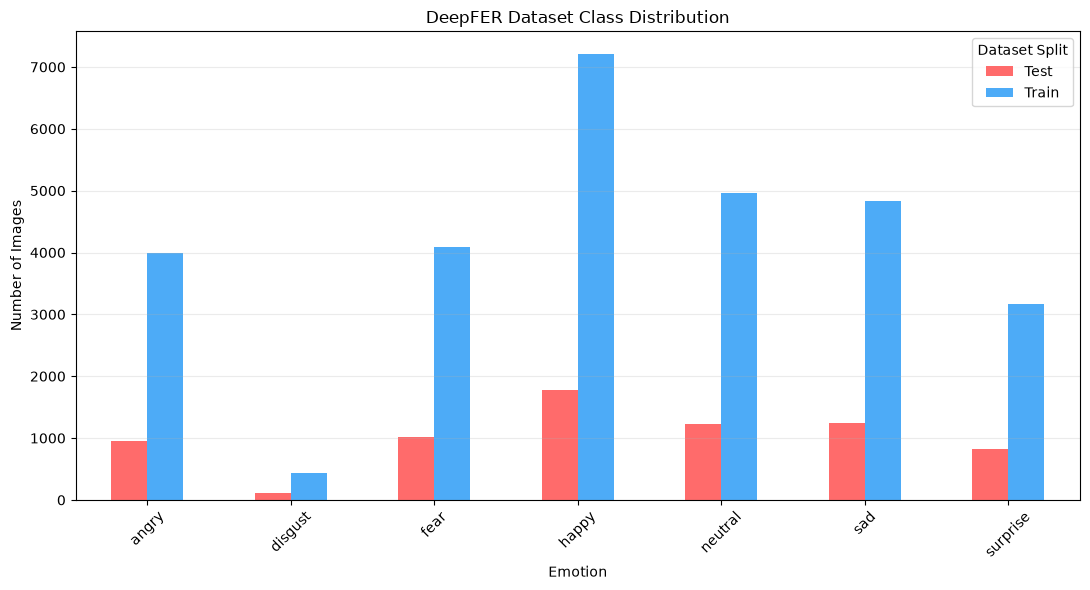

In [5]:
image_extensions = {".jpg", ".jpeg", ".png"}

records = []

for split_name, split_dir in {
    "Train": TRAIN_DIR,
    "Test": TEST_DIR
}.items():
    for emotion in emotion_classes:
        emotion_dir = split_dir / emotion

        count = sum(
            1 for file in emotion_dir.iterdir()
            if file.is_file() and file.suffix.lower() in image_extensions
        )

        records.append({
            "Split": split_name,
            "Emotion": emotion,
            "Image Count": count
        })

class_counts = pd.DataFrame(records)
class_counts

pivot_counts = class_counts.pivot(
    index="Emotion",
    columns="Split",
    values="Image Count"
)

ax = pivot_counts.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#ff6b6b", "#4dabf7"]
)

plt.title("DeepFER Dataset Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()


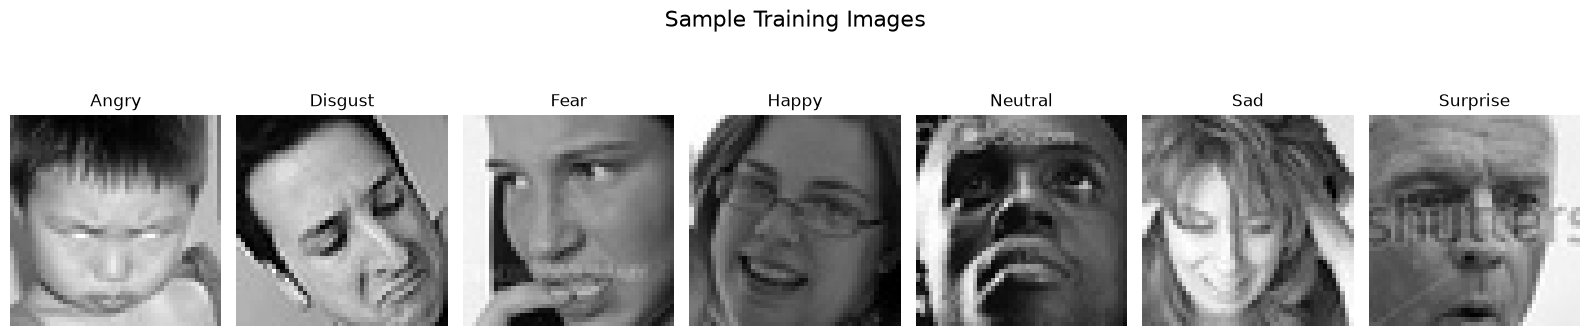

In [6]:
fig, axes = plt.subplots(1, len(emotion_classes), figsize=(16, 4))

for axis, emotion in zip(axes, emotion_classes):
    emotion_dir = TRAIN_DIR / emotion

    image_files = [
        file for file in emotion_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    image_path = image_files[0]
    image = Image.open(image_path)

    axis.imshow(image, cmap="gray")
    axis.set_title(emotion.capitalize())
    axis.axis("off")

plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
image_details = []

for emotion in emotion_classes:
    emotion_dir = TRAIN_DIR / emotion

    image_files = [
        file for file in emotion_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    for image_path in image_files[:100]:
        with Image.open(image_path) as image:
            image_details.append({
                "Emotion": emotion,
                "Width": image.width,
                "Height": image.height,
                "Mode": image.mode
            })

image_details_df = pd.DataFrame(image_details)

print("Image dimensions:")
display(
    image_details_df[["Width", "Height"]]
    .value_counts()
    .reset_index(name="Count")
)

print("\nImage modes:")
display(image_details_df["Mode"].value_counts())

Image dimensions:


,Width,Height,Count
0,48,48,700



Image modes:


Mode
L    700
Name: count, dtype: int64